In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np
import pydensecrf.densecrf as dcrf

ModuleNotFoundError: No module named 'pydensecrf'

In [2]:
from albumentations import (
    PadIfNeeded,
    HorizontalFlip,
    VerticalFlip,    
    CenterCrop,    
    Crop,
    Compose,
    Transpose,
    RandomRotate90,
    ElasticTransform,
    GridDistortion, 
    OpticalDistortion,
    RandomSizedCrop,
    OneOf,
    CLAHE,
    RandomContrast,
    RandomGamma,
    CoarseDropout,
    RandomBrightness
)
def  augment_flips_color():
    return Compose([
        RandomSizedCrop(min_max_height=(256, 512), 
                           height=512, 
                           width=512, p=0.5),    
        VerticalFlip(p=0.5),              
        RandomRotate90(p=0.5),
        OneOf([ElasticTransform(p=0.5, 
                            alpha=120, 
                            sigma=120 * 0.05, 
                            alpha_affine=120 * 0.03),
        GridDistortion(p=0.5),
        OpticalDistortion(p=1, distort_limit=2, shift_limit=0.5)           
        ], p=0.8),
        #RandomContrast(p=0.8),
        RandomBrightness(p=0.8),
        #RandomGamma(p=0.8),
        CoarseDropout(max_holes=16, max_height=16, max_width=16, p=0.7)])

aug = augment_flips_color()

In [3]:
train_slice_path = "/raid/zhuxihuan/data/body/MC_uncertainty_single_data/train_slice"
train_mask_path = "/raid/zhuxihuan/data/body/MC_uncertainty_single_data/train_mask"
test_slice_path = "/raid/zhuxihuan/data/body/single_npy_data/val_slice"
test_mask_path = "/raid/zhuxihuan/data/body/single_npy_data/val_mask"

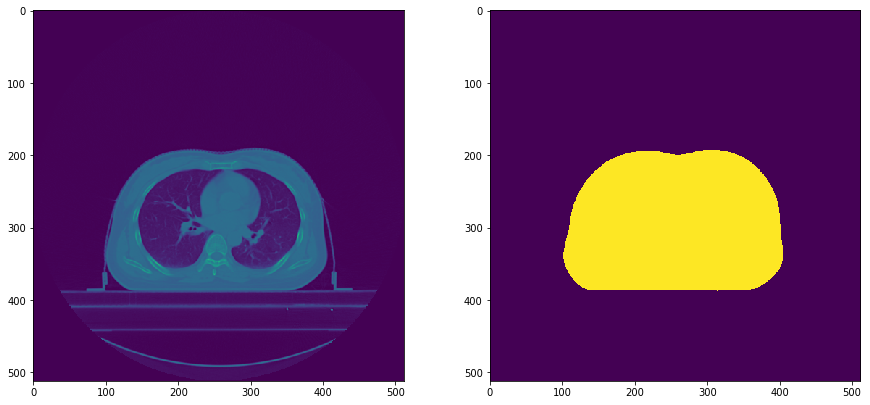

In [4]:
i = 34
img = np.load(train_slice_path + f"/{i}.npy")
img = np.squeeze(img)
plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.imshow(img)
msk = np.load(train_mask_path + f"/{i}.npy")
msk = np.squeeze(msk)
plt.subplot(2, 2, 2)
plt.imshow(msk)

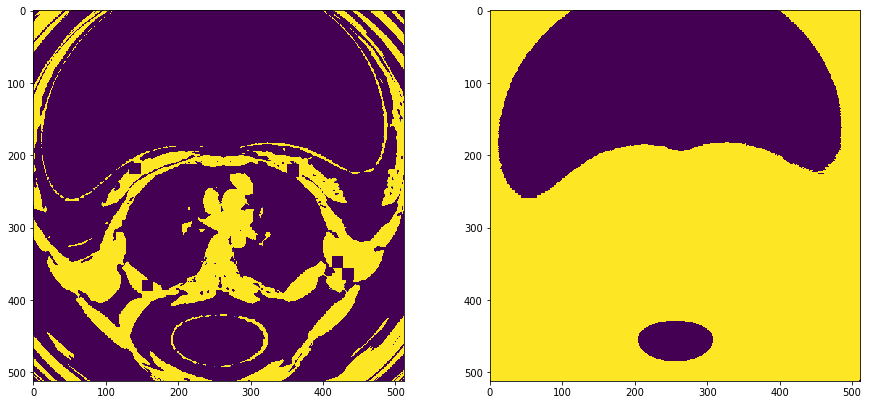

In [5]:
img = img.astype(np.float32)
kk = aug(image = img, mask=msk)
plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.imshow(kk["image"])
msk = np.load(train_mask_path + f"/{i}.npy")
msk = np.squeeze(msk)
plt.subplot(2, 2, 2)
plt.imshow(kk["mask"])